File saved: Figure_1c.pdf


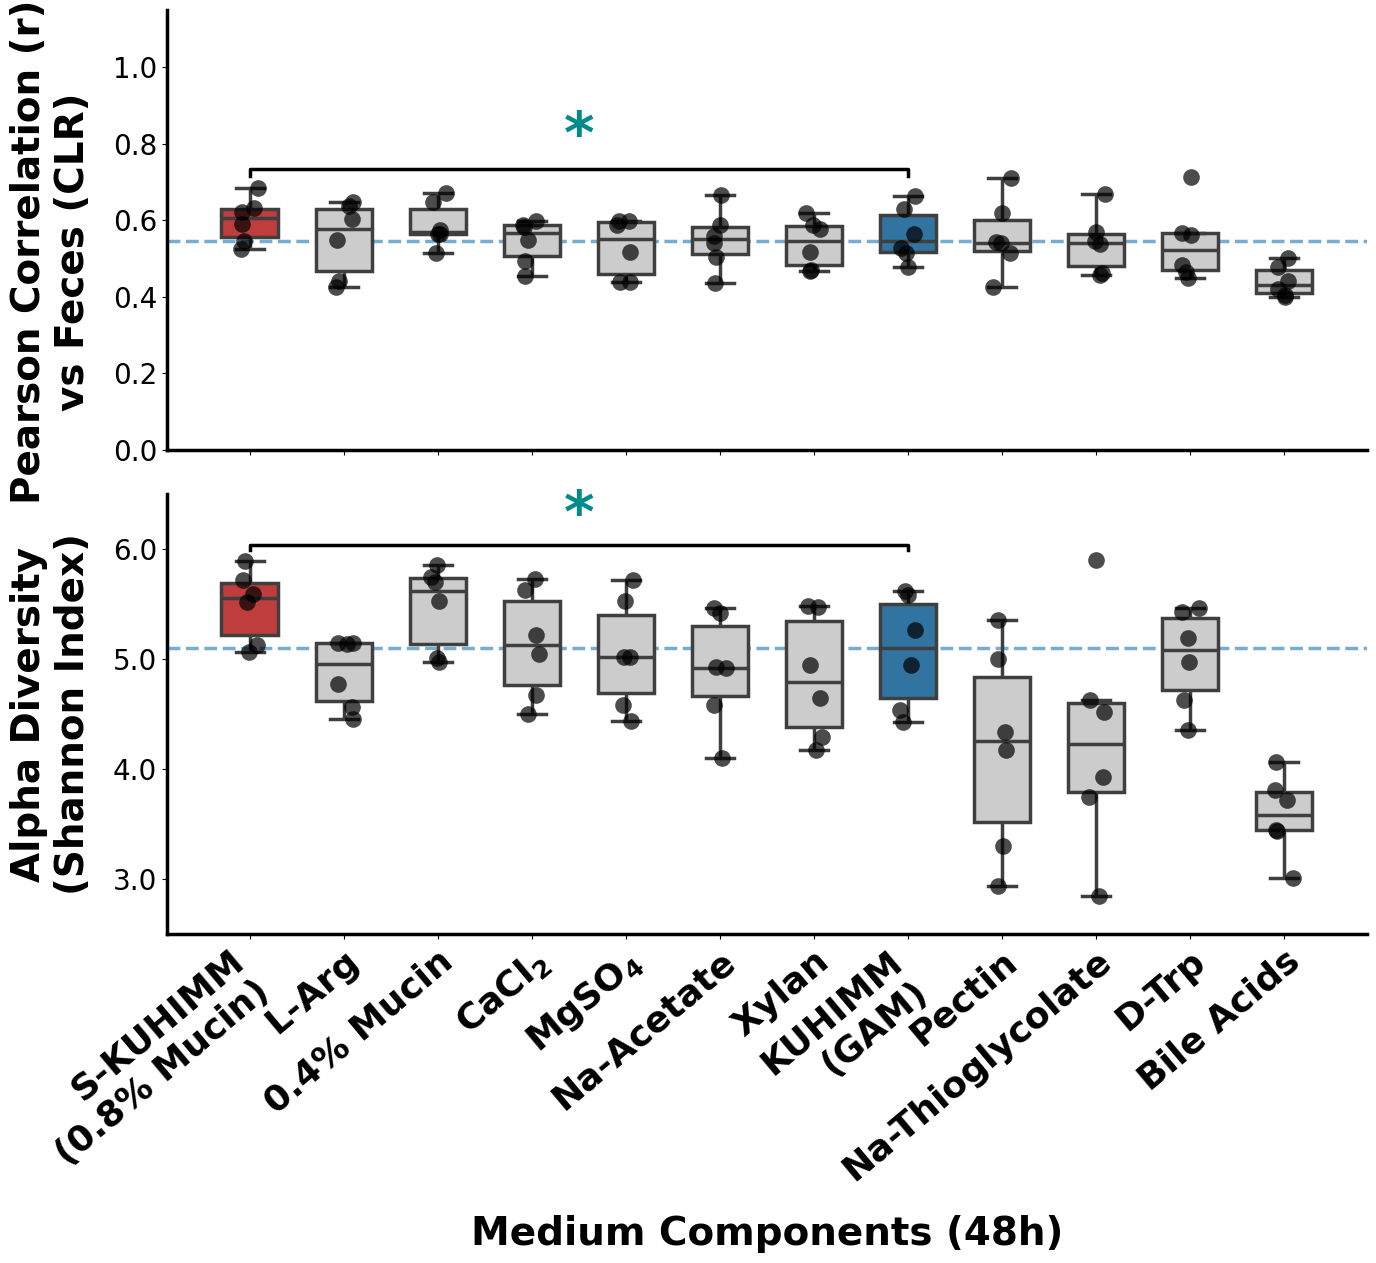

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.transforms as mtransforms
from scipy.stats import pearsonr, wilcoxon
from scipy.stats.mstats import gmean
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Global Plotting Configuration (Strict Nature Standards)
# =============================================================================
plt.rcParams.update({
    'font.size': 24,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'sans-serif'],
    'pdf.fonttype': 42,
    'axes.linewidth': 2.5,
    'mathtext.default': 'regular'
})

# Universal Settings for Significance Markers
STAR_COLOR = '#008B8B'  # Dark Turquoise
STAR_SIZE = 42

def add_stat_annotation(ax, x1, x2, y, h, text):
    """Draws a strict, professional statistical bracket with a colored asterisk."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2.5, c='k')
    ax.text((x1+x2)*0.5, y+h + 0.01, text, ha='center', va='bottom',
            color=STAR_COLOR, fontsize=STAR_SIZE, fontweight='bold')

# =============================================================================
# 1. Load Data
# =============================================================================
df_16s = pd.read_csv("(1c)_Medium_16S_Genus_level.csv")
df_shannon = pd.read_csv("(1c)_Medium_shannon.csv")

def extract_time(subj):
    if 'FEC' in subj: return '0h'
    elif '48h' in subj: return '48h'
    return 'Exclude'

df_16s['Time'] = df_16s['Subject'].apply(extract_time)
df_shannon['Time'] = df_shannon['Subject'].apply(extract_time)

tax_cols = [c for c in df_16s.columns if c.startswith('d__') or c.startswith('Unassigned')]
clusters = df_16s['Cluster'].unique()
features_list = [f for f in df_16s['Feature'].unique() if f != 'Feces']

label_map = {
    'GAM (KUHIMM)': 'KUHIMM\n(GAM)',
    '0.8% Mucin (S-KUHIMM)': 'S-KUHIMM\n(0.8% Mucin)',
    '0.4% Mucin': '0.4% Mucin',
    '0.4% Pectin': 'Pectin',
    '0.4% Xylan': 'Xylan',
    '0.3% Sodium acetate': 'Na-Acetate',
    '0.25% Sodium thioglycolate': 'Na-Thioglycolate',
    '0.1% L-Arginine': 'L-Arg',
    '0.1% D-Tryptophan': 'D-Trp',
    '0.025% Sodium cholate+0.025% Chenodeoxycholic acid': 'Bile Acids',
    '0.01% Magnesium sulfate Heptahydrate': 'MgSO$_4$',
    '0.01% Calcium chloride dihydrate': 'CaCl$_2$'
}

def clr_transform(x):
    x = np.array(x, dtype=float)
    if (x == 0).any():
        pseudo = x[x > 0].min() * 0.5 if (x > 0).any() else 1e-9
        x = np.where(x == 0, pseudo, x)
    return np.log(x / gmean(x))

# --- Process Top Panel Data (Stability) ---
results = []
for cl in clusters:
    df_cl = df_16s[df_16s['Cluster'] == cl]
    fec_row = df_cl[df_cl['Time'] == '0h']

    if len(fec_row) >= 1:
        fec_vals = fec_row[tax_cols].values[0].astype(float)
        for feat in features_list:
            feat_row = df_cl[(df_cl['Time'] == '48h') & (df_cl['Feature'] == feat)]
            if len(feat_row) >= 1:
                feat_vals = feat_row[tax_cols].values[0].astype(float)
                mask_any = (fec_vals > 0) | (feat_vals > 0)
                fec_filt, feat_filt = fec_vals[mask_any], feat_vals[mask_any]

                if len(fec_filt) > 3:
                    pseudo_fec = fec_filt[fec_filt > 0].min() * 0.5 if len(fec_filt[fec_filt > 0]) > 0 else 1e-6
                    pseudo_feat = feat_filt[feat_filt > 0].min() * 0.5 if len(feat_filt[feat_filt > 0]) > 0 else 1e-6
                    fec_imputed = np.where(fec_filt == 0, pseudo_fec, fec_filt)
                    feat_imputed = np.where(feat_filt == 0, pseudo_feat, feat_filt)
                    corr, _ = pearsonr(clr_transform(fec_imputed), clr_transform(feat_imputed))
                    results.append({'Donor': cl, 'Condition': label_map.get(feat, feat), 'Pearson_CLR': corr})

df_top = pd.DataFrame(results)
order_1c = df_top.groupby('Condition')['Pearson_CLR'].median().sort_values(ascending=False).index.tolist()

# --- Process Bottom Panel Data (Shannon Diversity) ---
depth_cols = [c for c in df_shannon.columns if 'depth' in c]
df_shannon['Max_Shannon'] = df_shannon[depth_cols].max(axis=1)

shannon_results = []
for cl in clusters:
    df_cl = df_shannon[df_shannon['Cluster'] == cl]
    for feat in features_list:
        feat_row = df_cl[(df_cl['Time'] == '48h') & (df_cl['Feature'] == feat)]
        if len(feat_row) >= 1:
            shannon_results.append({'Donor': cl, 'Condition': label_map.get(feat, feat), 'Max_Shannon': feat_row['Max_Shannon'].values[0]})

df_bot = pd.DataFrame(shannon_results)

# =============================================================================
# 2. Visualization
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True, gridspec_kw={'hspace': 0.1})
gam_name = 'KUHIMM\n(GAM)'
skuhimm_name = 'S-KUHIMM\n(0.8% Mucin)'

# Color Coding: Base (Blue), Target (Red), Others (Gray)
palette_top = {c: '#1f77b4' if c == gam_name else ('#d62728' if c == skuhimm_name else '#cccccc') for c in order_1c}

# --- Top Panel ---
ax_top = axes[0]
gam_median_top = df_top[df_top['Condition'] == gam_name]['Pearson_CLR'].median()
ax_top.axhline(gam_median_top, color='#1f77b4', linestyle='--', linewidth=2.5, alpha=0.6, zorder=0)

sns.boxplot(x='Condition', y='Pearson_CLR', data=df_top, order=order_1c, palette=palette_top, width=0.6, ax=ax_top, showfliers=False, linewidth=2.5)
sns.stripplot(x='Condition', y='Pearson_CLR', data=df_top, order=order_1c, color='black', alpha=0.7, size=12, jitter=True, ax=ax_top)

ax_top.set_ylim(0.0, 1.15)
# ** FIX: Shift label slightly downwards (y=0.45) to prevent top clipping **
ax_top.set_ylabel("Pearson Correlation (r)\nvs Feces (CLR)", fontsize=28, fontweight='bold', labelpad=15, y=0.45)
ax_top.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Explicitly force Y-axis labels to normal weight and size 20 (Matching 1b)
labels_top = ax_top.set_yticklabels(['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=20)
for label in labels_top:
    label.set_fontweight('normal')

# Targeted Statistics (GAM vs S-KUHIMM)
if gam_name in order_1c and skuhimm_name in order_1c:
    gam_idx = order_1c.index(gam_name)
    skuhimm_idx = order_1c.index(skuhimm_name)
    gam_data = df_top[df_top['Condition'] == gam_name].sort_values('Donor')['Pearson_CLR'].values
    skuhimm_data = df_top[df_top['Condition'] == skuhimm_name].sort_values('Donor')['Pearson_CLR'].values
    min_len = min(len(gam_data), len(skuhimm_data))

    if min_len >= 3:
        p = wilcoxon(gam_data[:min_len], skuhimm_data[:min_len]).pvalue
        if p < 0.05:
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*'
            y_max = df_top[df_top['Condition'].isin([gam_name, skuhimm_name])]['Pearson_CLR'].max()
            add_stat_annotation(ax_top, min(gam_idx, skuhimm_idx), max(gam_idx, skuhimm_idx), y_max + 0.03, 0.02, sig)

# --- Bottom Panel ---
ax_bot = axes[1]
gam_median_bot = df_bot[df_bot['Condition'] == gam_name]['Max_Shannon'].median()
ax_bot.axhline(gam_median_bot, color='#1f77b4', linestyle='--', linewidth=2.5, alpha=0.6, zorder=0)

sns.boxplot(x='Condition', y='Max_Shannon', data=df_bot, order=order_1c, palette=palette_top, width=0.6, ax=ax_bot, showfliers=False, linewidth=2.5)
sns.stripplot(x='Condition', y='Max_Shannon', data=df_bot, order=order_1c, color='black', alpha=0.7, size=12, jitter=True, ax=ax_bot)

ax_bot.set_ylim(2.5, 6.5)
ax_bot.set_ylabel("Alpha Diversity\n(Shannon Index)", fontsize=28, fontweight='bold', labelpad=15)
ax_bot.set_xlabel("Medium Components (48h)", fontsize=28, fontweight='bold', labelpad=20)
ax_bot.set_yticks([3.0, 4.0, 5.0, 6.0])

# Explicitly force Y-axis labels to normal weight and size 20
labels_bot = ax_bot.set_yticklabels(['3.0', '4.0', '5.0', '6.0'], fontsize=20)
for label in labels_bot:
    label.set_fontweight('normal')

# Targeted Statistics (GAM vs S-KUHIMM)
if gam_name in order_1c and skuhimm_name in order_1c:
    gam_data_bot = df_bot[df_bot['Condition'] == gam_name].sort_values('Donor')['Max_Shannon'].values
    skuhimm_data_bot = df_bot[df_bot['Condition'] == skuhimm_name].sort_values('Donor')['Max_Shannon'].values
    min_len = min(len(gam_data_bot), len(skuhimm_data_bot))

    if min_len >= 3:
        p_bot = wilcoxon(gam_data_bot[:min_len], skuhimm_data_bot[:min_len]).pvalue
        if p_bot < 0.05:
            sig = '***' if p_bot < 0.001 else '**' if p_bot < 0.01 else '*'
            y_max_bot = df_bot[df_bot['Condition'].isin([gam_name, skuhimm_name])]['Max_Shannon'].max()
            add_stat_annotation(ax_bot, min(gam_idx, skuhimm_idx), max(gam_idx, skuhimm_idx), y_max_bot + 0.1, 0.05, sig)

# --- X-axis Label Offset Logic ---
ax_bot.set_xticklabels(order_1c, rotation=40, ha='right', rotation_mode='anchor', fontsize=26, fontweight='bold')
dx_points = -15 / 72.0
offset = mtransforms.ScaledTranslation(dx_points, 0, fig.dpi_scale_trans)

for label in ax_bot.get_xticklabels():
    if "KUHIMM" in label.get_text():
        label.set_transform(label.get_transform() + offset)

sns.despine()

# ** FIX: Force tight_layout to leave 6% extra space at the top of the entire figure **
plt.tight_layout(rect=[0, 0, 1, 0.94])

# Save output with extra padding to guarantee safety
output_file = "Figure_1c.pdf"
plt.savefig(output_file, dpi=600, transparent=True, bbox_inches='tight', pad_inches=0.2)
print(f"File saved: {output_file}")